# Target-candidate ensemble margin

Проверяем на всех 5 985 target-eligible примерах, описывает ли запас **ансамбля кандидатов** target hiding лучше, чем patched score одной clean-клетки. Геометрия не используется как предиктор: IoU нужен только для определения кандидатов заранее зафиксированного clean target.

Outcome пересчитывается из candidate trace тем же decode/NMS-протоколом, который используется в causal experiments. Старые labels показываются отдельно для pipeline audit.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'CandidateRoutingAndAttackPath' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0,str(REPO_ROOT))
from CandidateRoutingAndAttackPath.ensemble_margin import EnsembleMarginConfig, MODEL_FEATURES, run_ensemble_margin
sns.set_theme(style='whitegrid',context='notebook')
print(REPO_ROOT)

/Users/ashentide/PycharmProjects/PatchSuccessResearch


## 1. Расчёт

Model inference не выполняется: используются сохранённые top-50 candidates. Агрегация 5 985 изображений, обучение четырёх небольших моделей и bootstrap показывают прогресс через `tqdm`. Результаты дополнительно сохраняются в `outputs/ensemble_margin_v1`.

In [2]:
result = run_ensemble_margin(EnsembleMarginConfig(bootstrap_repeats=500))
features, candidates = result['features'], result['candidates']
metrics, models, predictions, test = result['metrics'], result['models'], result['predictions'], result['test']
display(result['summary'])
display(metrics.round(4))

ensemble margins:   0%|          | 0/5985 [00:00<?, ?image/s]

fit margin models:   0%|          | 0/4 [00:00<?, ?it/s]

bootstrap tracked_cell:   0%|          | 0/500 [00:00<?, ?it/s]

bootstrap clean_set_max:   0%|          | 0/500 [00:00<?, ?it/s]

bootstrap clean_set_ensemble:   0%|          | 0/500 [00:00<?, ?it/s]

bootstrap current_target_ensemble:   0%|          | 0/500 [00:00<?, ?it/s]

{'status': 'complete',
 'n_examples': 5985,
 'trace_hidden_rate': 0.34252297410192145,
 'old_trace_agreement': 0.9941520467836257,
 'n_pipeline_disagreements': 35,
 'tracked_cell_test_auc': 0.8681968202813051,
 'clean_set_ensemble_test_auc': 0.952330854102716,
 'best_model': 'current_target_ensemble',
 'best_test_auc': 0.9972359279062524,
 'limitations': ['Only the saved top-50 person candidates are available.',
  'Current-target ensemble is an endpoint proxy, not an independent mechanism.',
  'Predictive margin complements but does not replace causal interventions.']}

,model,n_train,n_test,threshold,roc_auc,average_precision,balanced_accuracy,precision,recall,auc_ci_low,auc_ci_high
3,current_target_ensemble,3535,2450,0.6980,0.9972,0.9954,0.9721,0.9792,0.9547,0.9960,0.9983
2,clean_set_ensemble,3535,2450,0.5742,0.9523,0.9280,0.8891,0.8517,0.8558,0.9436,0.9605
1,clean_set_max,3535,2450,0.7772,0.9323,0.9073,0.8819,0.9549,0.7831,0.9206,0.9425
0,tracked_cell,3535,2450,0.5544,0.8682,0.6593,0.8318,0.6786,0.8808,0.8527,0.8818


## 2. Pipeline audit

Строки — старые labels, столбцы — trace-consistent outcome. Обнаружено 35/5 985 расхождений (agreement 99.42%): 27 старых hidden становятся visible в trace, 8 старых visible — hidden. Повторный стандартный `yolo.predict` на всех 35 спорных изображениях согласился с trace, поэтому проблема находится в сохранённом старом label run, а не в branch recombination. Все следующие графики используют `trace_target_hidden`.

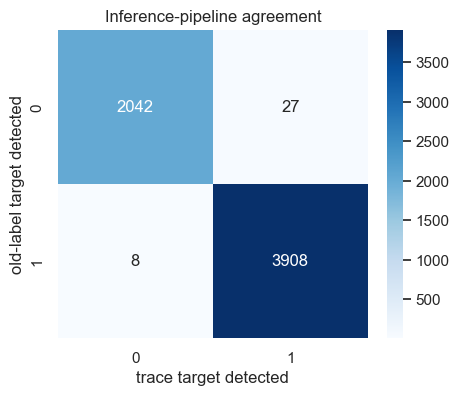

Agreement: 99.415%; disagreements: 35


In [3]:
agreement = pd.crosstab(features.target_detected.astype(int),features.trace_target_detected)
fig,ax=plt.subplots(figsize=(5,4))
sns.heatmap(agreement,annot=True,fmt='d',cmap='Blues',ax=ax)
ax.set(xlabel='trace target detected',ylabel='old-label target detected',title='Inference-pipeline agreement')
plt.show()
print(f"Agreement: {features.old_trace_agree.mean():.3%}; disagreements: {(~features.old_trace_agree).sum()}")

## 3. Кто удерживает target после патча?

Это прямой lineage experiment без классификатора. Для каждого visible target выбирается его самый уверенный post-NMS detection и проверяется flat index: это исходная tracked-клетка, другая клетка из clean target set или candidate, которого в clean target set не было. `Pre-existing` здесь означает тот же flat index, имевший clean IoU ≥ 0.5 и score ≥ 0.01; это операциональная lineage, а не утверждение об идентичности всех внутренних признаков.

In [ ]:
LINEAGE_ORDER=['target_hidden','original_tracked_candidate','other_preexisting_clean_candidate','new_recruited_candidate']
LINEAGE_LABELS={'target_hidden':'target hidden','original_tracked_candidate':'original tracked','other_preexisting_clean_candidate':'other pre-existing clean candidate','new_recruited_candidate':'new recruited candidate'}
counts=features.lineage_outcome.value_counts().reindex(LINEAGE_ORDER,fill_value=0)
visible_counts=counts.drop('target_hidden')
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.barplot(x=[LINEAGE_LABELS[x] for x in counts.index],y=counts.values,ax=axes[0],palette='Set2')
axes[0].set(title='Outcome over all target-eligible examples',ylabel='examples',xlabel='')
axes[0].tick_params(axis='x',rotation=20)
axes[1].pie(visible_counts.values,labels=[LINEAGE_LABELS[x] for x in visible_counts.index],autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set2',3))
axes[1].set_title('Who supplies the final detection when target stays visible?')
plt.tight_layout(); plt.show()
lineage_table=pd.DataFrame({'count':visible_counts,'share_among_visible':visible_counts/visible_counts.sum()})
display(lineage_table)

### Вывод

Из 3 935 trace-visible targets только 617 (15.7%) удерживаются исходной tracked-клеткой. В 2 806 случаях (71.3%) итоговый detection даёт другой candidate, уже принадлежавший target set на clean endpoint; принципиально новый candidate отвечает за 512 случаев (13.0%). Следовательно, основной источник устойчивости к подавлению clean winner — резерв ранее существовавшего candidate ensemble, а не генерация нового route с нуля.

## 4. Один tracked candidate против ансамбля

`clean_set` фиксируется на clean endpoint и затем отслеживается на patched endpoint по тем же flat indices. Если ансамблевая гипотеза верна, его совокупный evidence должен разделять hidden/visible лучше, чем `patched_tracked_score`.

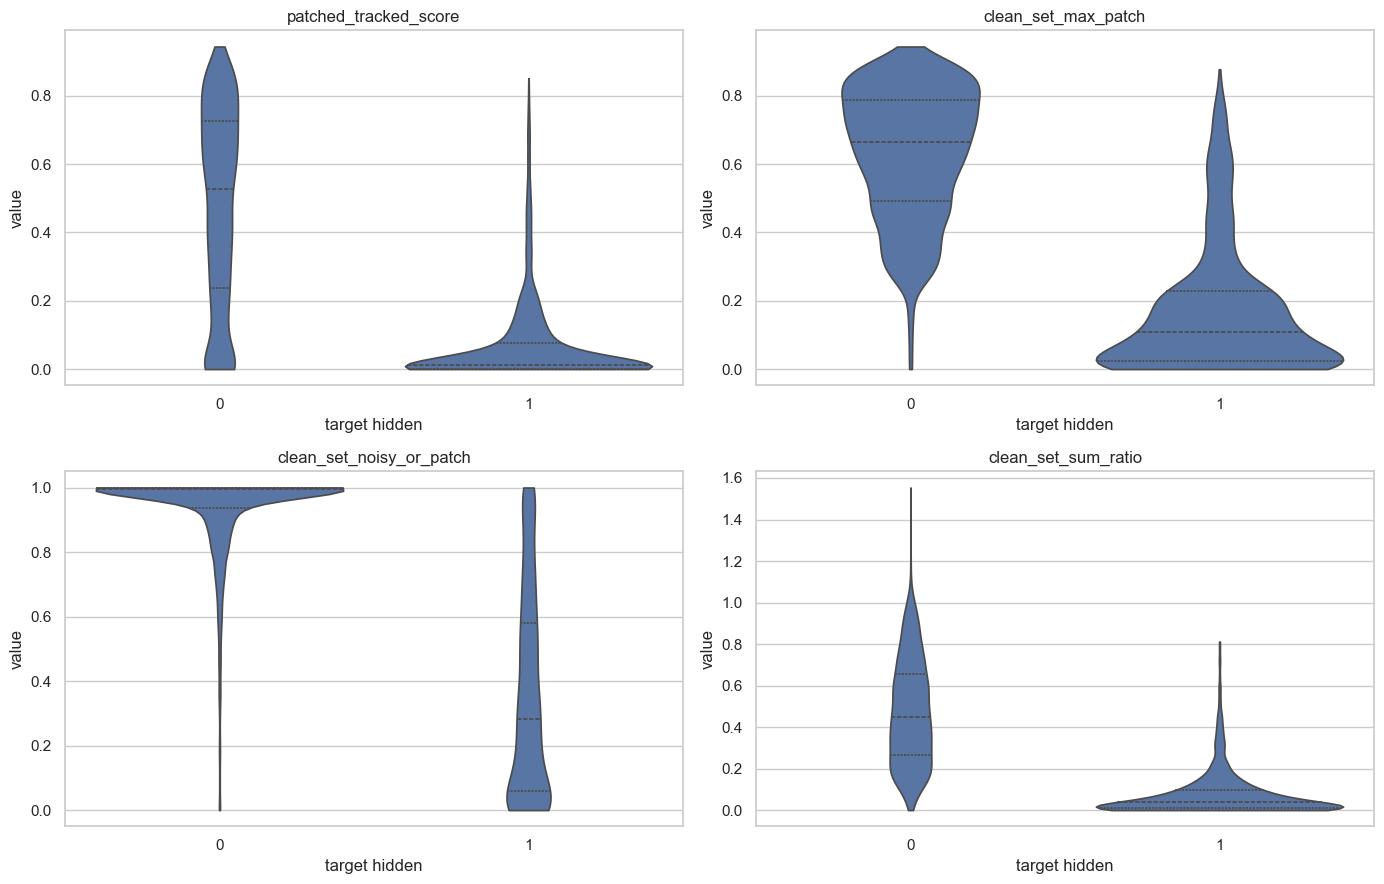

In [4]:
columns=['patched_tracked_score','clean_set_max_patch','clean_set_noisy_or_patch','clean_set_sum_ratio']
long=features.melt(id_vars='trace_target_hidden',value_vars=columns,var_name='metric',value_name='value')
fig,axes=plt.subplots(2,2,figsize=(14,9))
for ax,metric in zip(axes.flat,columns):
    sns.violinplot(data=long[long.metric==metric],x='trace_target_hidden',y='value',inner='quartile',cut=0,ax=ax)
    ax.set(title=metric,xlabel='target hidden')
plt.tight_layout(); plt.show()

## 5. Out-of-sample comparison

Главное сравнение — `tracked_cell` против `clean_set_ensemble` на test split. Из 5 985 примеров deterministic split оставляет 3 535 для обучения/выбора threshold и 2 450 только для финальной оценки (839 hidden, 1 611 visible). `ROC AUC` не использует один threshold: это вероятность того, что случайный hidden получит больший predicted risk, чем случайный visible. `Accuracy` — доля правильных ответов при threshold, выбранном только на train; `balanced accuracy` усредняет отдельно accuracy на hidden и visible. `current_target_ensemble` является почти endpoint proxy: его membership уже использует patched overlap, поэтому он служит верхней диагностической границей, а не независимым объяснением.

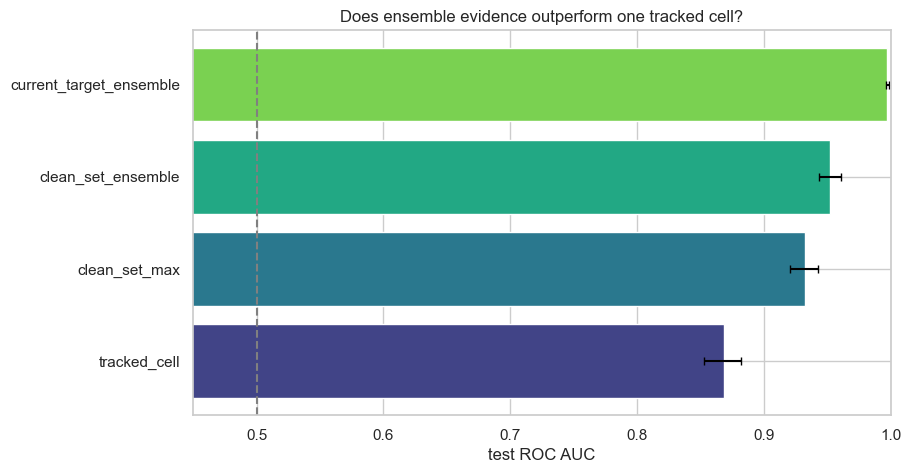

,model,n_train,n_test,threshold,roc_auc,average_precision,balanced_accuracy,precision,recall,auc_ci_low,auc_ci_high
3,current_target_ensemble,3535,2450,0.6980,0.9972,0.9954,0.9721,0.9792,0.9547,0.9960,0.9983
2,clean_set_ensemble,3535,2450,0.5742,0.9523,0.9280,0.8891,0.8517,0.8558,0.9436,0.9605
1,clean_set_max,3535,2450,0.7772,0.9323,0.9073,0.8819,0.9549,0.7831,0.9206,0.9425
0,tracked_cell,3535,2450,0.5544,0.8682,0.6593,0.8318,0.6786,0.8808,0.8527,0.8818


In [5]:
ordered=metrics.sort_values('roc_auc').set_index('model')
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(ordered.index,ordered.roc_auc,color=sns.color_palette('viridis',len(ordered)))
ax.errorbar(ordered.roc_auc,ordered.index,xerr=[ordered.roc_auc-ordered.auc_ci_low,ordered.auc_ci_high-ordered.roc_auc],fmt='none',color='black',capsize=3)
ax.axvline(.5,color='grey',ls='--')
ax.set(xlim=(.45,1),xlabel='test ROC AUC',title='Does ensemble evidence outperform one tracked cell?')
plt.show()
display(metrics.round(4))

Результат поддерживает ensemble margin: test ROC AUC tracked-cell равен 0.868 [0.853; 0.882], clean-set max — 0.932 [0.921; 0.943], полный clean-set ensemble — 0.952 [0.944; 0.961]. Интервалы tracked и ensemble не перекрываются. При train-selected threshold обычная accuracy равна 81.6%, 91.2% и 89.9%; balanced accuracy — 83.2%, 88.1% и 88.8% соответственно. Clean-set max имеет выше обычную accuracy за счёт высокой precision и меньшего recall, а полный ensemble лучше балансирует hidden и visible. Endpoint-proxy достигает AUC 0.997 и accuracy 97.8%, но не считается независимым механизмом, поскольку его membership уже использует patched overlap.

## 6. Calibration и состав margin

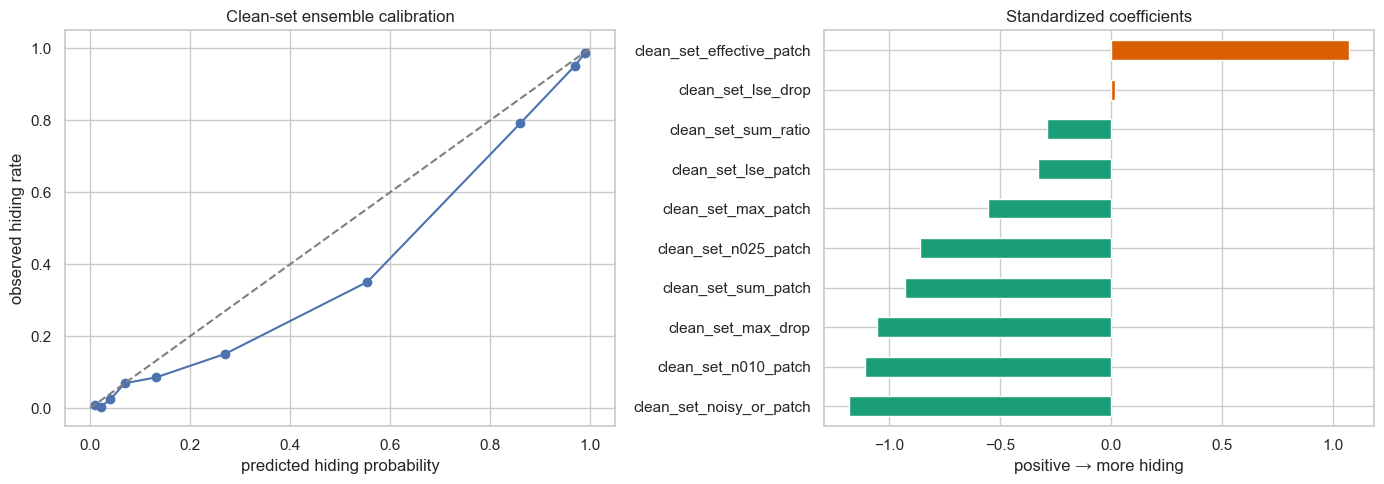

,decile,n,predicted,observed
0,"(0.00274, 0.0148]",245,0.009447,0.008163
1,"(0.0148, 0.0295]",245,0.021507,0.004082
2,"(0.0295, 0.0533]",245,0.040397,0.024490
3,"(0.0533, 0.0929]",245,0.069594,0.069388
4,"(0.0929, 0.188]",245,0.132375,0.085714
5,"(0.188, 0.381]",245,0.270442,0.151020
6,"(0.381, 0.738]",245,0.554728,0.351020
7,"(0.738, 0.943]",245,0.860422,0.791837
8,"(0.943, 0.983]",245,0.969159,0.951020
9,"(0.983, 0.999]",245,0.990168,0.987755


In [6]:
primary='clean_set_ensemble'
prob=predictions[primary]
cal=pd.DataFrame({'prob':prob,'hidden':test.trace_target_hidden.to_numpy()})
cal['decile']=pd.qcut(cal.prob,10,duplicates='drop')
cal=cal.groupby('decile',observed=True).agg(n=('hidden','size'),predicted=('prob','mean'),observed=('hidden','mean')).reset_index()
coef=pd.Series(models[primary].named_steps['clf'].coef_[0],index=MODEL_FEATURES[primary]).sort_values()
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(cal.predicted,cal.observed,'o-'); axes[0].plot([0,1],[0,1],'--',color='grey')
axes[0].set(xlabel='predicted hiding probability',ylabel='observed hiding rate',title='Clean-set ensemble calibration')
coef.plot.barh(ax=axes[1],color=['#d95f02' if x>0 else '#1b9e77' for x in coef])
axes[1].set(title='Standardized coefficients',xlabel='positive → more hiding')
plt.tight_layout(); plt.show()
display(cal)

Margin является не только одним максимальным score: полный clean-set ensemble превосходит clean-set max на 0.020 AUC. Медианный patched tracked score равен 0.526 для visible и 0.012 для hidden, но ансамблевый max разделяет группы ещё сильнее (0.664 против 0.110), а median score-mass ratio — 0.447 против 0.039. Коэффициенты коррелированных агрегатов нельзя по отдельности трактовать причинно; содержательный результат — общий out-of-sample выигрыш ансамбля.

## 7. Candidate bars для отдельных изображений

Одинаковый `flat_index` — один и тот же candidate до и после патча. Красная линия — detection threshold.

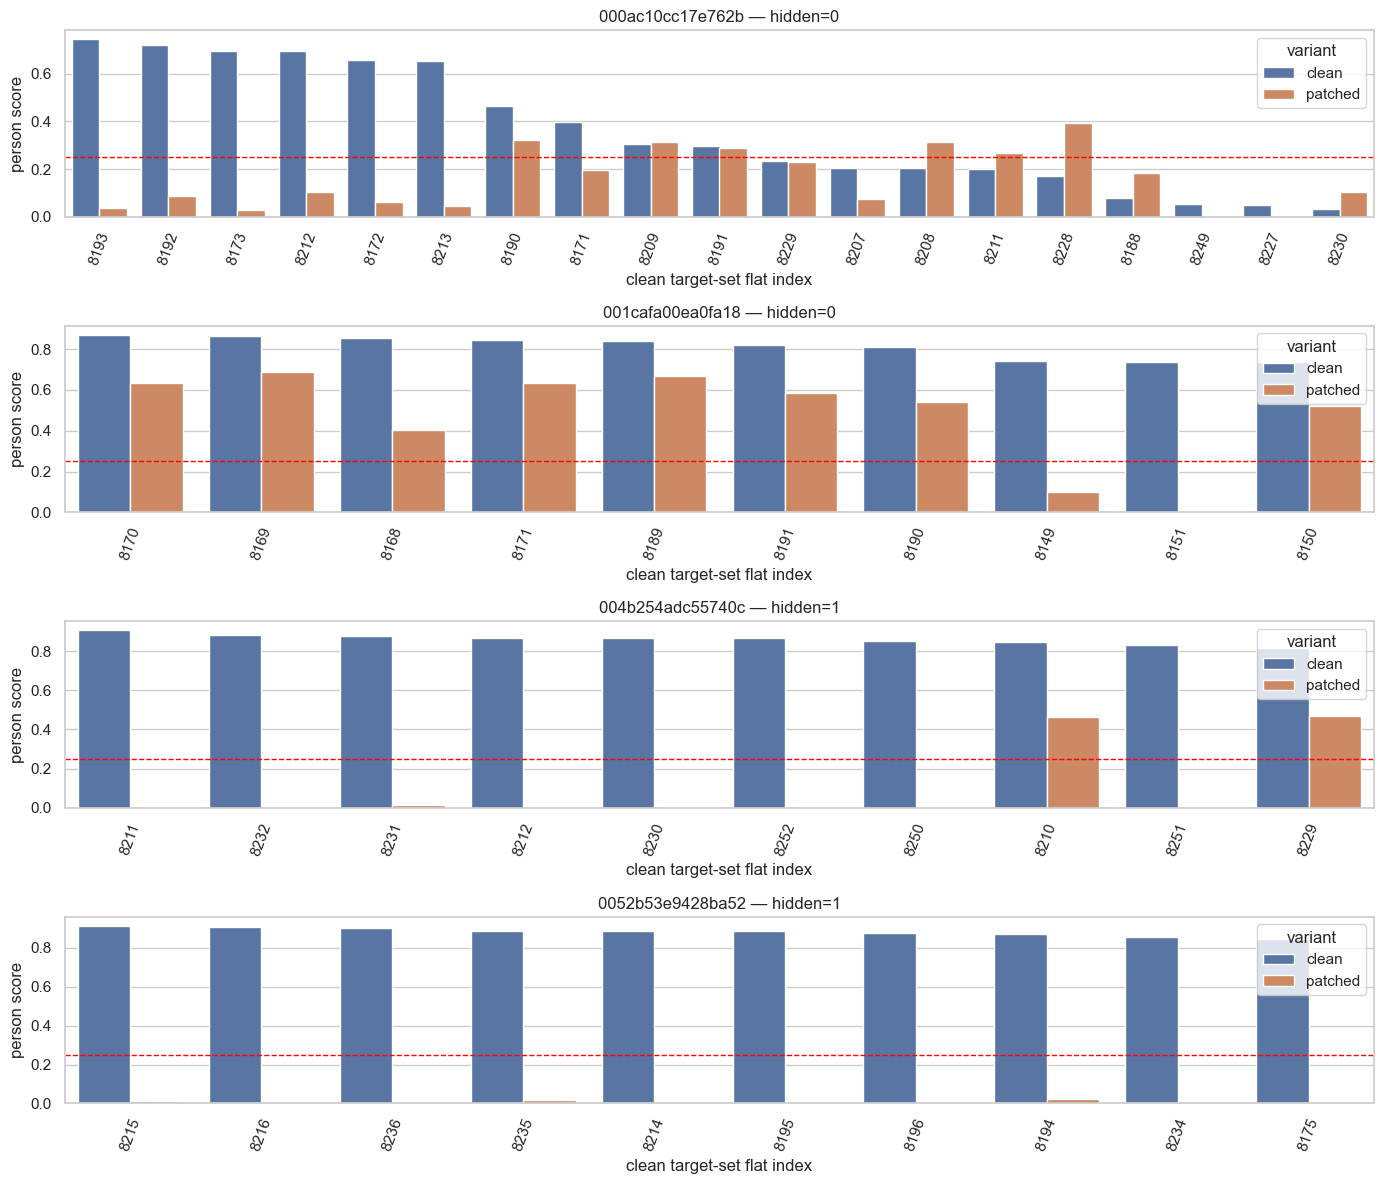

In [7]:
picked=pd.concat([g.sort_values('example_id').head(2) for _,g in test.groupby('trace_target_hidden')])
fig,axes=plt.subplots(len(picked),1,figsize=(14,3*len(picked)),squeeze=False)
for ax,row in zip(axes.flat,picked.itertuples()):
    q=candidates[(candidates.example_id==row.example_id)&candidates.in_clean_target_set].copy()
    q['candidate']=q.flat_index.astype(str)
    sns.barplot(data=q,x='candidate',y='decoded_score',hue='variant',ax=ax)
    ax.axhline(.25,color='red',ls='--',lw=1)
    ax.set(title=f'{row.example_id} — hidden={row.trace_target_hidden}',xlabel='clean target-set flat index',ylabel='person score')
    ax.tick_params(axis='x',rotation=70)
plt.tight_layout(); plt.show()

## 8. Итоговые четыре числа

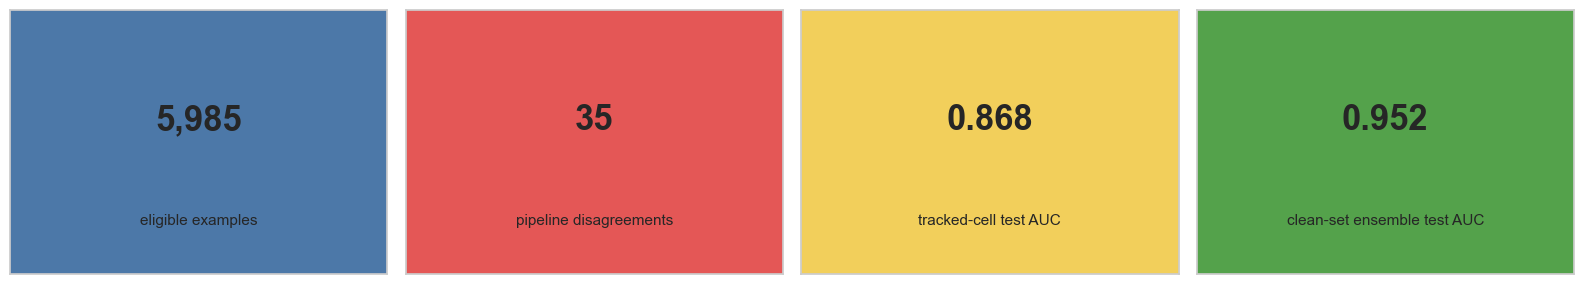

{'status': 'complete',
 'n_examples': 5985,
 'trace_hidden_rate': 0.34252297410192145,
 'old_trace_agreement': 0.9941520467836257,
 'n_pipeline_disagreements': 35,
 'tracked_cell_test_auc': 0.8681968202813051,
 'clean_set_ensemble_test_auc': 0.952330854102716,
 'best_model': 'current_target_ensemble',
 'best_test_auc': 0.9972359279062524,
 'limitations': ['Only the saved top-50 person candidates are available.',
  'Current-target ensemble is an endpoint proxy, not an independent mechanism.',
  'Predictive margin complements but does not replace causal interventions.']}

In [8]:
summary=result['summary']
cards=[('eligible examples',summary['n_examples'],'#4c78a8'),('pipeline disagreements',summary['n_pipeline_disagreements'],'#e45756'),('tracked-cell test AUC',summary['tracked_cell_test_auc'],'#f2cf5b'),('clean-set ensemble test AUC',summary['clean_set_ensemble_test_auc'],'#54a24b')]
fig,axes=plt.subplots(1,4,figsize=(16,3))
for ax,(label,value,color) in zip(axes,cards):
    ax.set_facecolor(color); ax.text(.5,.58,f'{value:.3f}' if isinstance(value,float) else f'{value:,}',ha='center',va='center',fontsize=25,fontweight='bold')
    ax.text(.5,.20,label,ha='center',va='center',fontsize=11,wrap=True); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
display(summary)

## Ограничение

Predictive accuracy не является новым causal intervention. Причинная часть аргумента опирается на branch factorial и candidate-set oracle. Для статьи положительный ensemble-margin результат затем нужно перенести на другую модель или другой патч.